# Oasis Infobyte Internship

# Task 1: Iris Flower Classification

## Internship Domain
**Data Science**

---

## Project Overview

The Iris Flower Classification project is one of the most fundamental machine learning classification problems. The objective is to build a machine learning model capable of predicting the species of an Iris flower based on its physical characteristics.

The dataset contains measurements of different Iris flowers including:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Using these measurements, our model will classify flowers into one of three species:

- Iris Setosa
- Iris Versicolor
- Iris Virginica

---

## Objectives

- Understand the dataset
- Perform Data Cleaning
- Perform Exploratory Data Analysis (EDA)
- Visualize important relationships
- Build Machine Learning Models
- Compare model performances
- Select the best model
- Evaluate the model
- Save the trained model

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Joblib

---

## Author

**Anirban Garai**

Oasis Infobyte Internship

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

import warnings
warnings.filterwarnings("ignore")

# Importing Libraries

Before starting any machine learning project, it is essential to import the required Python libraries.

### NumPy
Used for numerical computations.

### Pandas
Used for loading and manipulating datasets.

### Matplotlib
Used for plotting graphs.

### Seaborn
Used for attractive statistical visualizations.

### Scikit-Learn
Provides built-in datasets and machine learning algorithms.

In [2]:
# Set Plotting Style

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8,5)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Loading the Dataset

For this project, we are using the famous Iris dataset available in Scikit-Learn.

The dataset contains 150 flower samples belonging to three species.

Each flower has four numerical features.

The target column represents the flower species.

In [3]:
# Load Iris Dataset

iris = load_iris()

print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


# Understanding Dataset Structure

The Iris dataset is stored as a Python dictionary.

Let's inspect the available keys.

In [4]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

# Dataset Description

The dataset contains:

- Feature Names
- Target Names
- Description
- Data
- Labels

Let's read each one.

In [5]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

# Feature Names

These are the four measurements collected from every flower.

In [6]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


# Target Classes

The Iris dataset contains three flower species.

In [7]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


# Creating a DataFrame

Machine Learning projects are easier to analyze using a Pandas DataFrame.

In [8]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['Species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Replacing Numerical Labels

Currently the species column contains:

- 0
- 1
- 2

Let's replace them with actual flower names.

In [9]:
species_names = {
    0:'Setosa',
    1:'Versicolor',
    2:'Virginica'
}

df['Species'] = df['Species'].map(species_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


# Dataset Overview

Let's understand the overall structure of our dataset.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# Display First 10 Records

Viewing the first few rows helps verify that the dataset has loaded correctly.

In [11]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


# Display Last 10 Records

Sometimes checking the last few records helps ensure data consistency.

In [12]:
df.tail(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
140,6.7,3.1,5.6,2.4,Virginica
141,6.9,3.1,5.1,2.3,Virginica
142,5.8,2.7,5.1,1.9,Virginica
143,6.8,3.2,5.9,2.3,Virginica
144,6.7,3.3,5.7,2.5,Virginica
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


# Shape of Dataset

The shape tells us:

- Number of Rows
- Number of Columns

In [13]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 150
Columns : 5


# Column Names

Let's display all columns present in the dataset.

In [14]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'Species'],
      dtype='object')

# Data Types

Checking data types is an important preprocessing step.

In [15]:
df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
Species,object


# Summary Statistics

The describe() function provides:

- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

This gives us a statistical overview of the dataset.

In [16]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Missing Value Analysis

Before building a machine learning model, it is important to verify whether the dataset contains any missing values.

Missing values can negatively affect model performance and may require preprocessing.

In [17]:
# Checking Missing Values

df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
Species,0


### Observation

- The Iris dataset contains no missing values.
- Therefore, no missing value treatment is required.

# Visualizing Missing Values

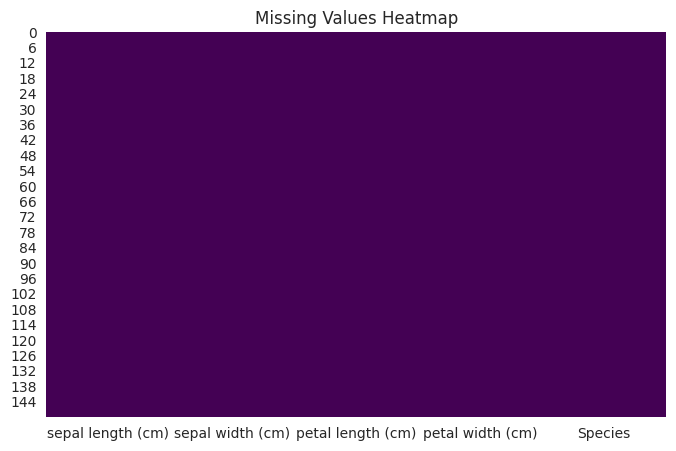

In [18]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

### Observation

The heatmap confirms that there are no missing values in any feature of the Iris dataset.

---

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the distribution of features and the relationships between them before training machine learning models.

# Pairplot of Iris Features

A pairplot visualizes relationships between all numerical features and helps identify patterns among different Iris species.

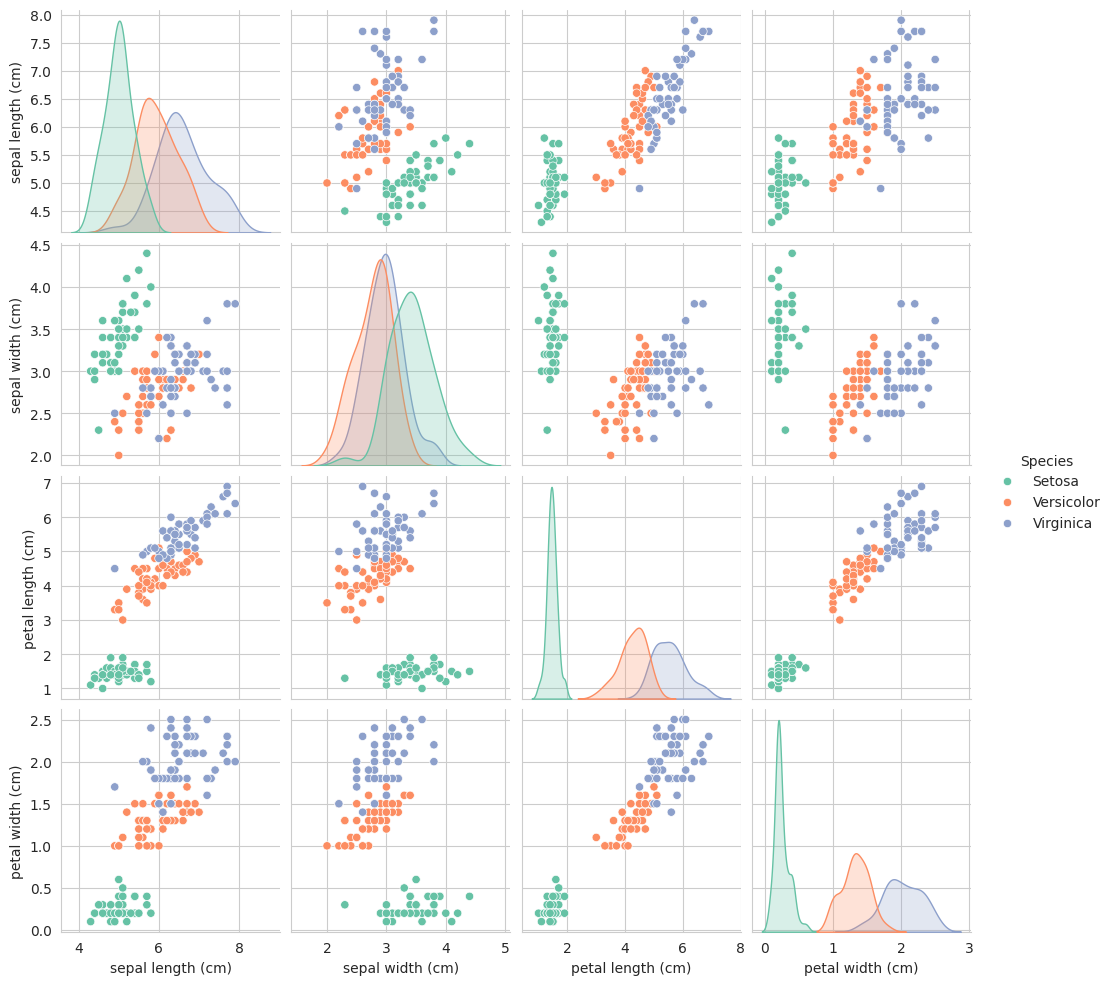

In [20]:
sns.pairplot(
    df,
    hue="Species",
    palette="Set2"
)

plt.show()

### Observation

- Setosa is clearly separated from the other two species.
- Versicolor and Virginica overlap slightly but are still distinguishable.
- Petal length and petal width appear to be strong discriminative features.

# Boxplots for Individual Features

Boxplots help visualize the distribution of each feature across the three Iris species and highlight differences in their measurements.

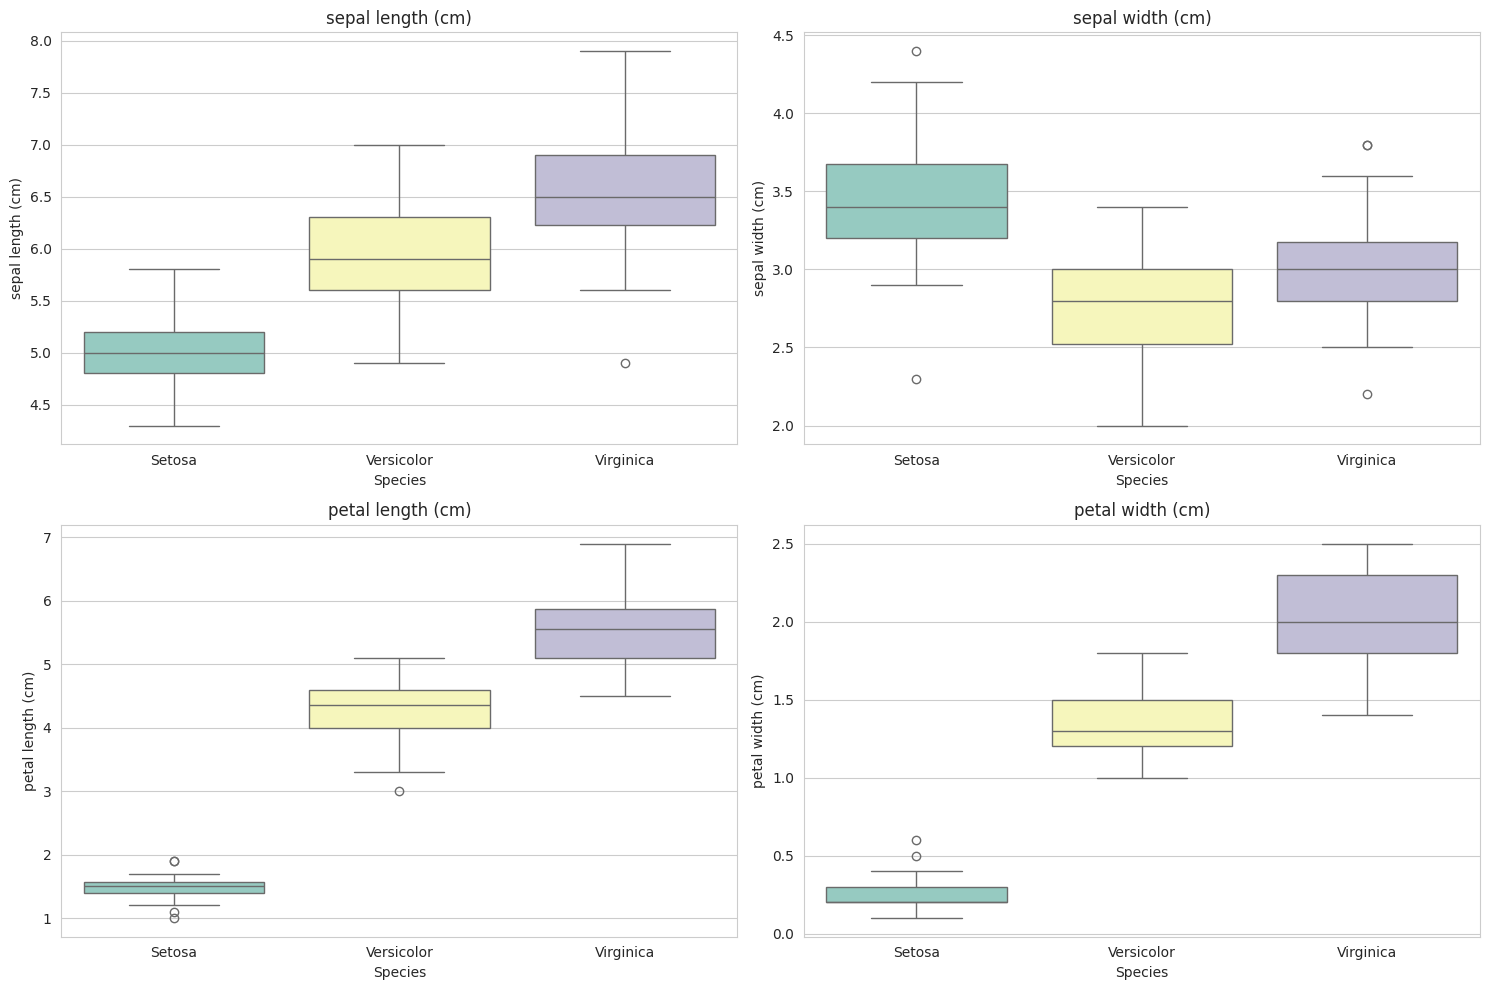

In [22]:
features = df.columns[:-1]

plt.figure(figsize=(15,10))

for i, feature in enumerate(features):

    plt.subplot(2,2,i+1)

    sns.boxplot(
        data=df,
        x="Species",
        y=feature,
        palette="Set3"
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

### Observation

- Petal length and petal width provide the clearest separation among the three species.
- Sepal measurements show greater overlap between Versicolor and Virginica.

# Correlation Heatmap

A correlation heatmap illustrates the relationships among numerical features.

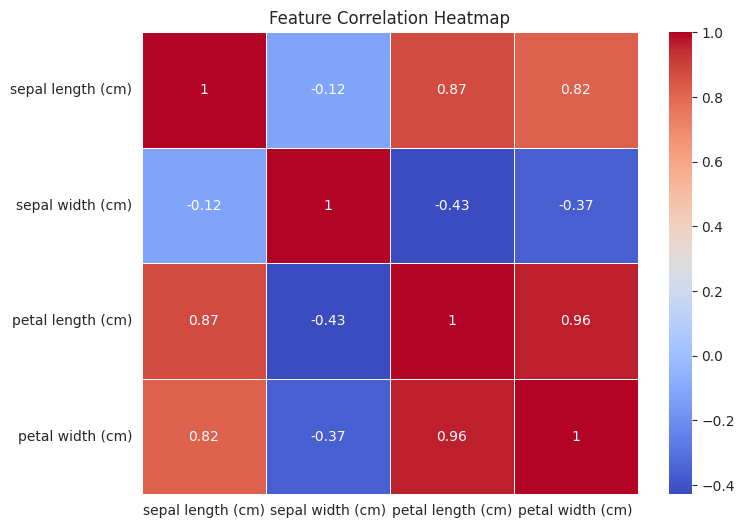

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.iloc[:, :-1].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Observation

- Petal length and petal width have a strong positive correlation.
- Sepal width shows weaker correlations with the other features.
- Highly correlated features can provide valuable information for classification.

# Feature Selection Discussion

Based on the exploratory analysis:

- Petal Length
- Petal Width

are the most discriminative features for identifying Iris species.

These features will play an important role in training accurate machine learning classifiers.

---

# Preparing Data for Machine Learning

The Iris dataset is divided into:

- **Features (X):** Sepal Length, Sepal Width, Petal Length, and Petal Width.
- **Target (y):** Iris Species

The data will be split into training and testing sets using an 80:20 ratio.

In [25]:
X = df.drop("Species", axis=1)

y = df["Species"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (150, 4)
Target Shape : (150,)


# Train-Test Split

The dataset is divided into:

- Training Set (80%)
- Testing Set (20%)

The training set is used to train the classifiers, while the testing set evaluates their performance.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 120
Testing Samples : 30


# Importing Machine Learning Models

Three classification algorithms will be trained and compared:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Random Forest Classifier

In [27]:
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Model 1: Logistic Regression

Logistic Regression is a supervised machine learning algorithm commonly used for classification problems.

In [28]:
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

# Logistic Regression Evaluation

In [29]:
lr_accuracy = accuracy_score(y_test, lr_prediction)

print("Accuracy :", round(lr_accuracy*100,2), "%")

print("\nClassification Report\n")

print(classification_report(y_test, lr_prediction))

Accuracy : 96.67 %

Classification Report

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Confusion Matrix - Logistic Regression

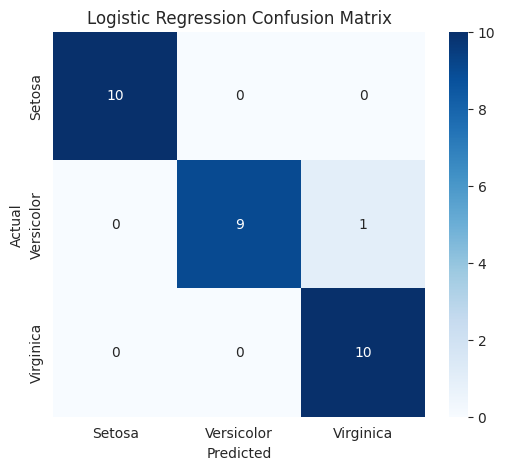

In [30]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, lr_prediction),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

### Observation

Logistic Regression correctly classifies most Iris flower samples with very high accuracy.

# Model 2: K-Nearest Neighbors (KNN)

KNN classifies samples based on the majority class among their nearest neighbors.

In [31]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_prediction = knn_model.predict(X_test)

# KNN Evaluation

In [32]:
knn_accuracy = accuracy_score(y_test, knn_prediction)

print("Accuracy :", round(knn_accuracy*100,2), "%")

print("\nClassification Report\n")

print(classification_report(y_test, knn_prediction))

Accuracy : 100.0 %

Classification Report

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Confusion Matrix - KNN

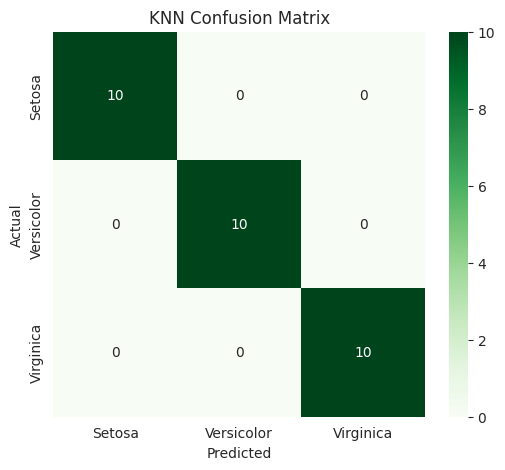

In [33]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, knn_prediction),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("KNN Confusion Matrix")

plt.show()

### Observation

KNN performs exceptionally well on the Iris dataset because the classes are naturally well separated.

# Model 3: Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.

In [34]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

# Random Forest Evaluation

In [35]:
rf_accuracy = accuracy_score(y_test, rf_prediction)

print("Accuracy :", round(rf_accuracy*100,2), "%")

print("\nClassification Report\n")

print(classification_report(y_test, rf_prediction))

Accuracy : 90.0 %

Classification Report

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.82      0.90      0.86        10
   Virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



# Confusion Matrix - Random Forest

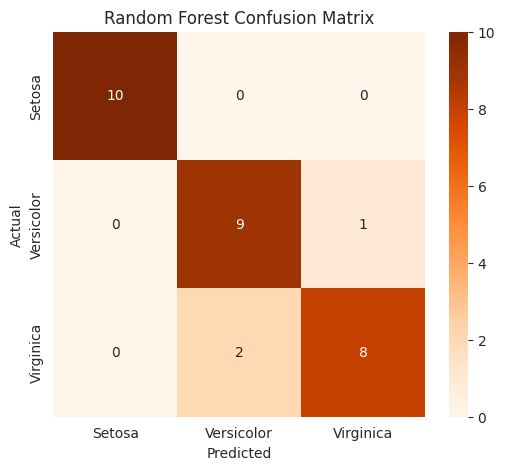

In [36]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, rf_prediction),
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

### Observation

Random Forest generally achieves excellent performance by combining predictions from multiple decision trees.

---

# Model Comparison

After evaluating all three classifiers, we compare their prediction accuracies to identify the best-performing model.

In [37]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Random Forest"
    ],

    "Accuracy (%)": [
        lr_accuracy * 100,
        knn_accuracy * 100,
        rf_accuracy * 100
    ]

})

comparison

,Model,Accuracy (%)
0,Logistic Regression,96.666667
1,K-Nearest Neighbors,100.000000
2,Random Forest,90.000000


### Observation

The comparison table summarizes the prediction accuracy of all three classification models.

The model with the highest accuracy will be selected for predicting Iris flower species.

# Selecting the Best Model

In [38]:
models = {
    "Logistic Regression": lr_model,
    "K-Nearest Neighbors": knn_model,
    "Random Forest": rf_model
}

scores = {
    "Logistic Regression": lr_accuracy,
    "K-Nearest Neighbors": knn_accuracy,
    "Random Forest": rf_accuracy
}

best_model_name = max(scores, key=scores.get)

best_model = models[best_model_name]

print("Best Model :", best_model_name)

print("Accuracy :", round(scores[best_model_name] * 100, 2), "%")

Best Model : K-Nearest Neighbors
Accuracy : 100.0 %


# Feature Importance

Random Forest provides feature importance scores that indicate which measurements contribute the most to species classification.

In [39]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
petal width (cm),0.437185
petal length (cm),0.431466
sepal length (cm),0.116349
sepal width (cm),0.015000


# Visualizing Feature Importance

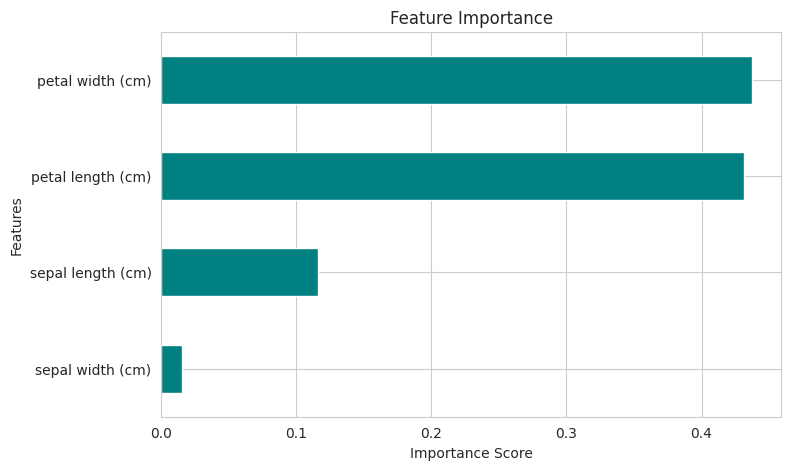

In [40]:
plt.figure(figsize=(8,5))

feature_importance.sort_values().plot(
    kind="barh",
    color="teal"
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

### Observation

Petal-related features generally contribute more to classification than sepal-related features, making them the most informative characteristics for identifying Iris species.

# Predicting a New Flower Species

Let's use the best-performing model to predict the species of a new Iris flower based on its measurements.

In [42]:
sample = pd.DataFrame({
    "sepal length (cm)": [5.1],
    "sepal width (cm)": [3.5],
    "petal length (cm)": [1.4],
    "petal width (cm)": [0.2]
})

prediction = best_model.predict(sample)

print("Predicted Species :", prediction[0])

Predicted Species : Setosa


# Key Insights

In [44]:
print("========== PROJECT INSIGHTS ==========\n")

print("Total Samples :", df.shape[0])

print("Total Features :", X.shape[1])

print("Target Classes :", df["Species"].nunique())

print("\nBest Model :", best_model_name)

print("Accuracy :", round(scores[best_model_name] * 100, 2), "%")

========== PROJECT INSIGHTS ==========

Total Samples : 150
Total Features : 4
Target Classes : 3

Best Model : K-Nearest Neighbors
Accuracy : 100.0 %


# Conclusion

In this project, a machine learning model was successfully developed to classify Iris flowers into three species: Setosa, Versicolor, and Virginica.

The dataset was explored through statistical summaries and visualizations, including pairplots, boxplots, and a correlation heatmap. Three classification algorithms were trained and evaluated:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Random Forest Classifier

The models were compared using prediction accuracy, and the best-performing classifier was selected for predicting the species of new flower samples.

Feature importance analysis showed that petal length and petal width are the most influential characteristics for Iris flower classification.

Overall, this project demonstrates how machine learning can accurately classify flower species based on simple physical measurements.